In [2]:
# ============================================
# WALMART DATA CLEANING & PREPARATION PIPELINE
# ============================================

import pandas as pd
import numpy as np
from pathlib import Path

def load_csv_safe(path: str) -> pd.DataFrame:
    """Safely load a CSV file with clear error messaging."""
    file = Path(path)
    if not file.exists():
        raise FileNotFoundError(f"Required file missing: {path}")
    return pd.read_csv(path)

def clean_and_merge_walmart():
    """Load, merge, clean, and aggregate Walmart weekly sales data."""
    
    # 1) Load files
    sales = load_csv_safe("train.csv")
    features = load_csv_safe("features.csv")
    stores = load_csv_safe("stores.csv")

    # 2) Convert dates
    sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')
    features['Date'] = pd.to_datetime(features['Date'], errors='coerce')

    # Ensure no corrupted date rows
    sales = sales.dropna(subset=['Date'])
    features = features.dropna(subset=['Date'])

    # 3) Merge datasets
    df = (
        sales.merge(features, on=['Store', 'Date'], how='left')
             .merge(stores, on='Store', how='left')
    )

    # 4) Remove invalid values
    df = df[df['Weekly_Sales'] >= 0]

    # 5) Fill missing numeric values with median (safe for Prophet)
    numeric_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # 6) Add time features
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week

    # 7) Aggregate into global weekly sales
    weekly = df.groupby('Date', as_index=False)['Weekly_Sales'].sum()

    # 8) Export cleaned file
    weekly.to_csv("clean_walmart.csv", index=False)
    print("✔ clean_walmart.csv created successfully")

    return weekly

# Run cleaning pipeline
weekly_df = clean_and_merge_walmart()
weekly_df.head()


✔ clean_walmart.csv created successfully


,Date,Weekly_Sales
0,2010-02-05,49750875.98
1,2010-02-12,48336800.10
2,2010-02-19,48277902.33
3,2010-02-26,43970440.65
4,2010-03-05,46872715.16


In [3]:
# ============================================
# WALMART FORECASTING PIPELINE (PROPHET)
# ============================================

from prophet import Prophet

def build_forecast(input_csv="clean_walmart.csv", periods=12):
    """Train a Prophet model and generate weekly forecasts."""

    df = load_csv_safe(input_csv)
    
    # Prophet requires these column names
    df = df.rename(columns={"Date": "ds", "Weekly_Sales": "y"})

    # Initialize model
    model = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False
    )

    # Fit model
    print("⚙ Training Prophet model…")
    model.fit(df)

    # Create future dataframe
    future = model.make_future_dataframe(periods=periods, freq='W')

    # Predict
    forecast = model.predict(future)

    # Save full forecast output
    forecast.to_csv("walmart_forecast.csv", index=False)
    print("✔ walmart_forecast.csv created successfully")

    return forecast

# Run forecasting pipeline
forecast_df = build_forecast()
forecast_df[['ds','yhat','yhat_lower','yhat_upper']].tail()


21:00:44 - cmdstanpy - INFO - Chain [1] start processing


⚙ Training Prophet model…


21:00:44 - cmdstanpy - INFO - Chain [1] done processing


✔ walmart_forecast.csv created successfully


,ds,yhat,yhat_lower,yhat_upper
150,2012-12-16,6.701910e+07,6.273529e+07,7.149309e+07
151,2012-12-23,6.584615e+07,6.162248e+07,7.034129e+07
152,2012-12-30,5.842677e+07,5.422485e+07,6.288798e+07
153,2013-01-06,4.833772e+07,4.397213e+07,5.273046e+07
154,2013-01-13,4.155305e+07,3.701357e+07,4.592460e+07


21:02:34 - cmdstanpy - INFO - Chain [1] start processing
21:02:34 - cmdstanpy - INFO - Chain [1] done processing


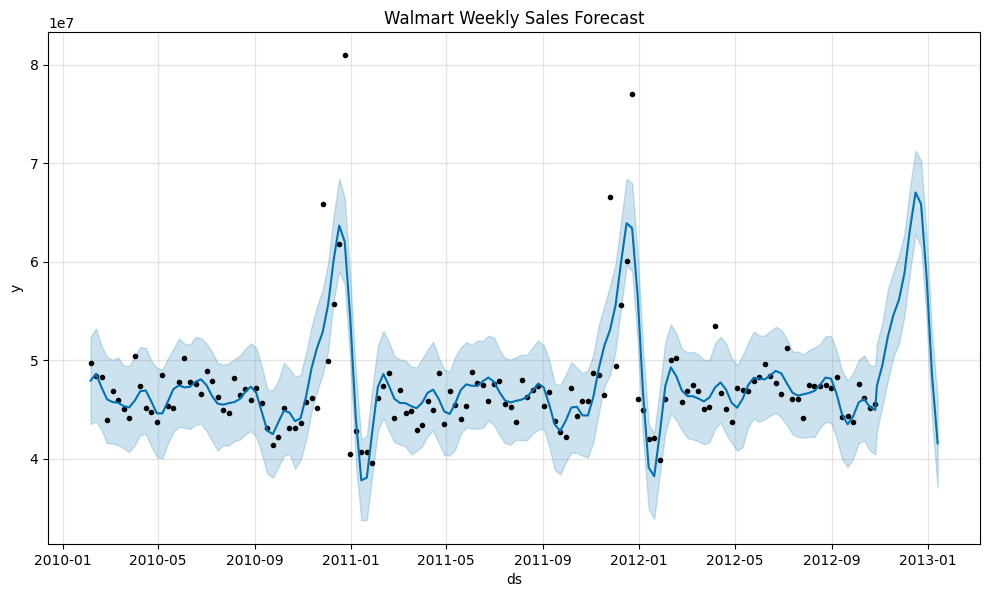

In [5]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Reload cleaned dataset
df = pd.read_csv("clean_walmart.csv")
df = df.rename(columns={"Date": "ds", "Weekly_Sales": "y"})

# Train model again (Prophet trains fast, don't worry)
model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
model.fit(df)

# Predict again
future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

# Plot
model.plot(forecast)
plt.title("Walmart Weekly Sales Forecast")
plt.show()


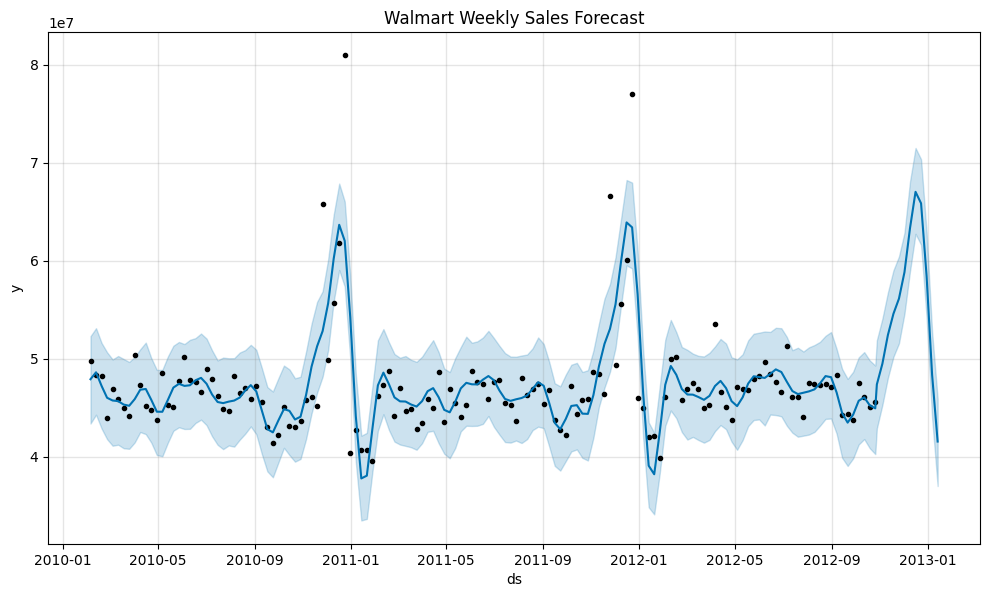

In [6]:
import matplotlib.pyplot as plt

model.plot(forecast_df)
plt.title("Walmart Weekly Sales Forecast")
plt.show()
